In [1]:

# ── Load results (handles both single-file and sharded output) ──────────────
import glob
import pandas as pd

OUTPUT_CSV = "results_dp_sbm_sparse_n500.csv"   # match OUTPUT_CSV in script_sparse_synthetic_graph.py

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# Fixed display order: dense-ish regime first, then the hard sparse one.
REGIME_ORDER = ["relatively_sparse", "sparse"]
REGIME_LABEL = {
    "relatively_sparse": r"relatively sparse  ($p=\log n/n$)",
    "sparse":            r"sparse  ($p=5/n$)",
}
regimes = [r for r in REGIME_ORDER if r in set(df["regime"])]

# Sanity table: what graphs did we actually get?
summary = (df.groupby("regime")
             .agg(N=("N", "first"), p=("p", "first"), q=("q", "first"),
                  mean_degree=("mean_degree", "mean"),
                  n_sigmas=("sigma", "nunique"), n_reps=("rep", "nunique"),
                  rows=("nmi", "size")))
display(summary.reindex(regimes))
df.head()

Loaded results_dp_sbm_sparse_n500.csv, 400 rows.


,N,p,q,mean_degree,n_sigmas,n_reps,rows
regime,,,,,,,
relatively_sparse,500,0.012429,0.001243,3.4154,5,20,200
sparse,500,0.010000,0.001000,2.7382,5,20,200


,regime,N,p,q,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,lcc_frac,n_components,n_isolated,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,0,edge_flip_vem,NaN,NaN,...,0.964,19,18,0.012429,0.001243,0.012429,0.000000,0.020665,0.006663,0.002851
1,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.964,19,18,0.012429,0.001243,0.012429,0.102088,0.006402,0.128044,0.000567
2,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,1,edge_flip_vem,NaN,NaN,...,0.978,11,9,0.012429,0.001243,0.012429,0.000000,0.019394,0.006592,0.000543
3,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,1,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.978,11,9,0.012429,0.001243,0.012429,0.103882,0.005993,0.126497,0.005601
4,relatively_sparse,500,0.012429,0.001243,0.5,75.261074,2,edge_flip_vem,NaN,NaN,...,0.966,17,15,0.012429,0.001243,0.012429,0.004773,0.011462,0.027160,0.005864


,n_graphs,mean_degree,lcc_frac_mean,lcc_frac_min,lcc_frac_max,n_components,n_isolated
regime,,,,,,,
relatively_sparse,20,3.4154,0.9637,0.946,0.98,18.35,16.7
sparse,20,2.7382,0.9199,0.900,0.94,36.55,31.8


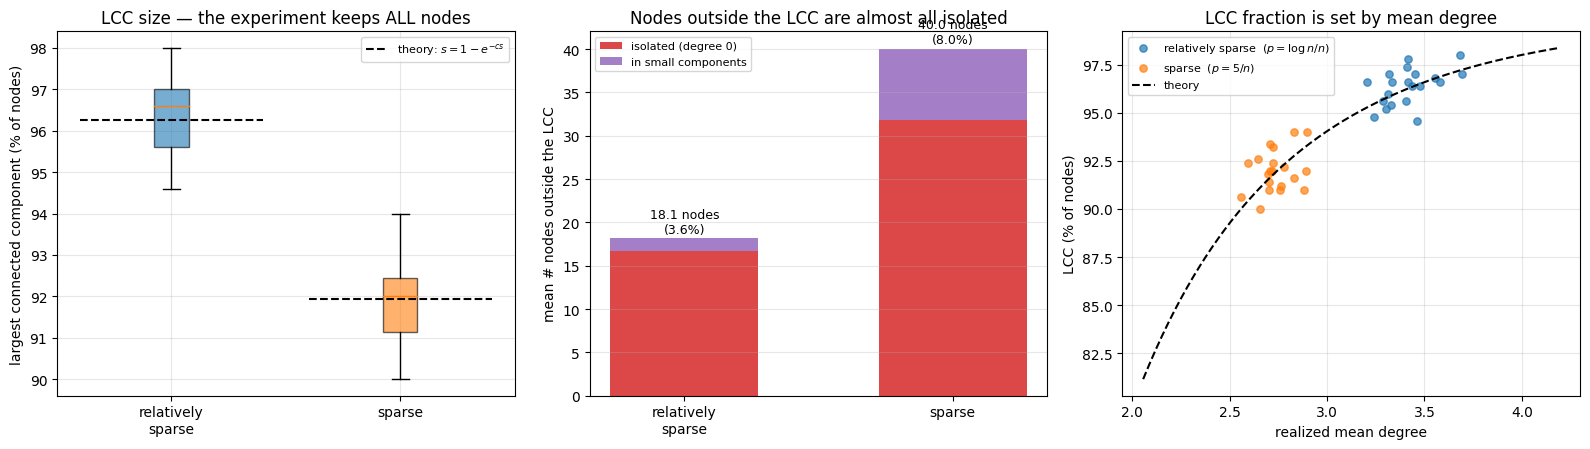

NMI ceiling from isolated nodes alone: relatively_sparse ~ 0.967   sparse ~ 0.936


In [2]:
# ── Connectivity of the generated graphs ───────────────────────────────────
# The experiment runs on the FULL graph, connected or not -- nothing is
# filtered or extracted. These columns are recorded purely so the degree of
# fragmentation is visible here.
#
# Dedup note: the rep seed depends on (regime, rep) only, NOT on sigma, so
# the same graph is reused across every sigma and both methods. Without the
# drop_duplicates below, each graph would be counted 2*len(SIGMAS) times and
# the distributions would look far tighter than they are.
import numpy as np
import matplotlib.pyplot as plt

graphs = df.drop_duplicates(subset=["regime", "rep"])[
    ["regime", "rep", "N", "mean_degree", "lcc_size", "lcc_frac",
     "n_components", "n_isolated"]
].copy()
graphs["non_lcc"] = graphs["N"] - graphs["lcc_size"]

stats = (graphs.groupby("regime")
               .agg(n_graphs=("rep", "size"),
                    mean_degree=("mean_degree", "mean"),
                    lcc_frac_mean=("lcc_frac", "mean"),
                    lcc_frac_min=("lcc_frac", "min"),
                    lcc_frac_max=("lcc_frac", "max"),
                    n_components=("n_components", "mean"),
                    n_isolated=("n_isolated", "mean"))
               .reindex(regimes).round(4))
display(stats)

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) LCC fraction -- boxplot per regime, with the theoretical giant-component
#     fraction s solving s = 1 - exp(-c*s) drawn as a reference line.
ax = axes[0]
data = [graphs[graphs["regime"] == r]["lcc_frac"].values * 100 for r in regimes]
bp = ax.boxplot(data, patch_artist=True, labels=[r.replace("_", "\n") for r in regimes])
for patch, i in zip(bp["boxes"], range(len(data))):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.6)
for i, r in enumerate(regimes):
    c = graphs[graphs["regime"] == r]["mean_degree"].mean()
    if c > 1:                      # supercritical: solve s = 1 - exp(-c s)
        s = 0.5
        for _ in range(200):
            s = 1 - np.exp(-c * s)
        ax.plot([i + 0.6, i + 1.4], [s * 100, s * 100], color="black",
                linestyle="--", linewidth=1.5,
                label="theory: $s=1-e^{-cs}$" if i == 0 else None)
ax.set_ylabel("largest connected component (% of nodes)")
ax.set_title("LCC size — the experiment keeps ALL nodes")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# (b) where the non-LCC nodes go: isolated vs in small components
ax = axes[1]
x = np.arange(len(regimes))
iso = [graphs[graphs["regime"] == r]["n_isolated"].mean() for r in regimes]
rest = [graphs[graphs["regime"] == r]["non_lcc"].mean() - i for r, i in zip(regimes, iso)]
ax.bar(x, iso, 0.55, label="isolated (degree 0)", color=colors[3], alpha=0.85)
ax.bar(x, rest, 0.55, bottom=iso, label="in small components", color=colors[4], alpha=0.85)
for xi, (a, b) in enumerate(zip(iso, rest)):
    ax.text(xi, a + b + 0.6, f"{a + b:.1f} nodes\n({(a + b) / graphs['N'].iloc[0]:.1%})",
            ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([r.replace("_", "\n") for r in regimes])
ax.set_ylabel("mean # nodes outside the LCC")
ax.set_title("Nodes outside the LCC are almost all isolated")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)

# (c) LCC fraction vs realized mean degree -- the driver of everything above
ax = axes[2]
for i, r in enumerate(regimes):
    g = graphs[graphs["regime"] == r]
    ax.scatter(g["mean_degree"], g["lcc_frac"] * 100, s=28, alpha=0.7,
               color=colors[i % len(colors)], label=REGIME_LABEL[r])
cc = np.linspace(max(1.01, graphs["mean_degree"].min() - 0.5),
                 graphs["mean_degree"].max() + 0.5, 200)
ss = np.full_like(cc, 0.5)
for _ in range(200):
    ss = 1 - np.exp(-cc * ss)
ax.plot(cc, ss * 100, color="black", linestyle="--", linewidth=1.5, label="theory")
ax.set_xlabel("realized mean degree")
ax.set_ylabel("LCC (% of nodes)")
ax.set_title("LCC fraction is set by mean degree")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"NMI ceiling from isolated nodes alone: "
      + "   ".join(f"{r} ~ {1 - graphs[graphs['regime'] == r]['n_isolated'].mean() / graphs['N'].iloc[0]:.3f}"
                   for r in regimes))

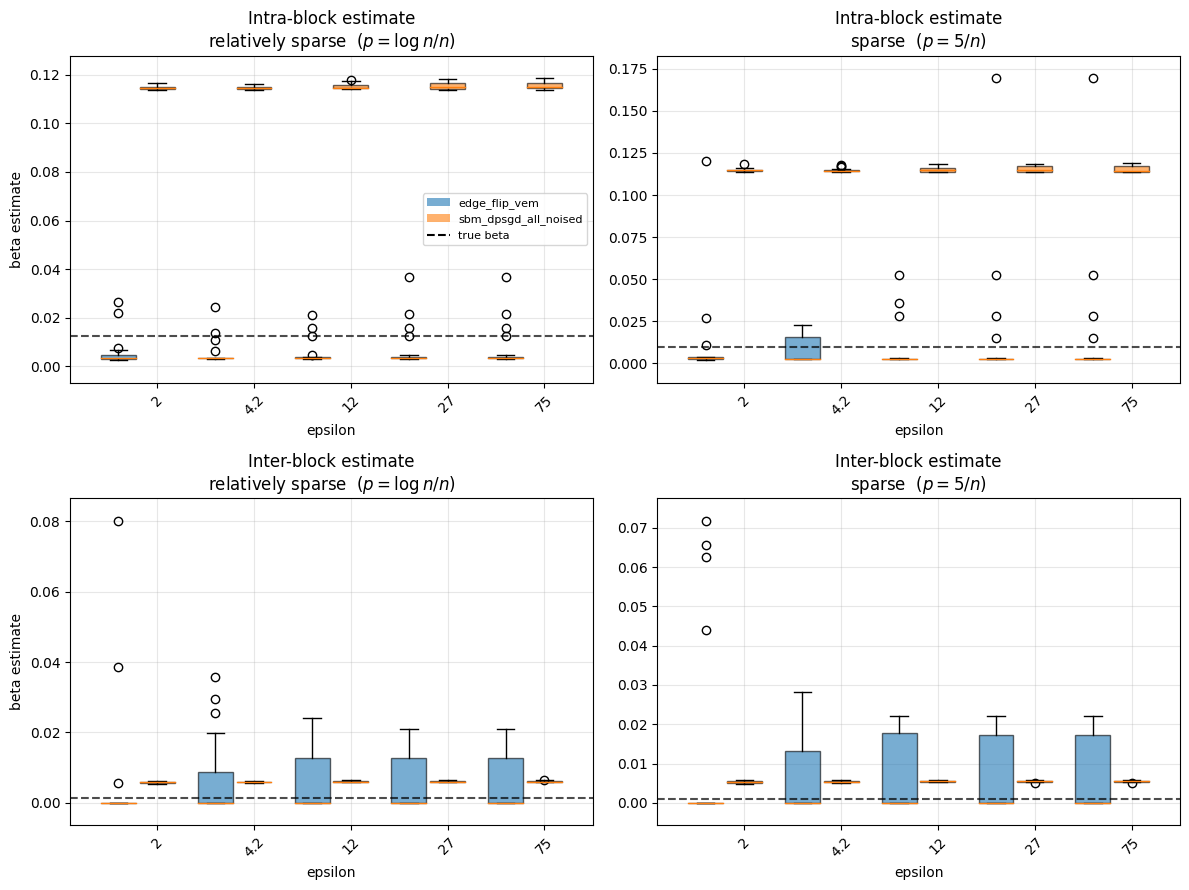

In [3]:

# ── Boxplots of estimated beta vs epsilon, one column per regime ────────────
# Rows: intra-block estimate (top), inter-block estimate (bottom).
# NOTE: unlike the N-sweep notebooks, y-limits are computed PER REGIME --
# the two regimes have different true betas (0.0124 vs 0.0100) and very
# different estimator spread, so a shared scale would flatten one of them.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, len(regimes), figsize=(6.0 * len(regimes), 9), squeeze=False)

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

for col, regime in enumerate(regimes):
    sub = df[df["regime"] == regime].copy()
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for row, (est_col, true_val, row_title) in enumerate([
        ("intra_est",   true_00, "Intra-block estimate"),
        ("beta_est_01", true_01, "Inter-block estimate"),
    ]):
        ax = axes[row, col]
        data, positions = [], []
        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        lo = min(min(d.min() for d in data), true_val)
        hi = max(max(d.max() for d in data), true_val)
        ax.set_ylim(*pad(lo, hi))
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title}\n{REGIME_LABEL[regime]}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

for r in range(2):
    axes[r, 0].set_ylabel("beta estimate")

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true beta"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

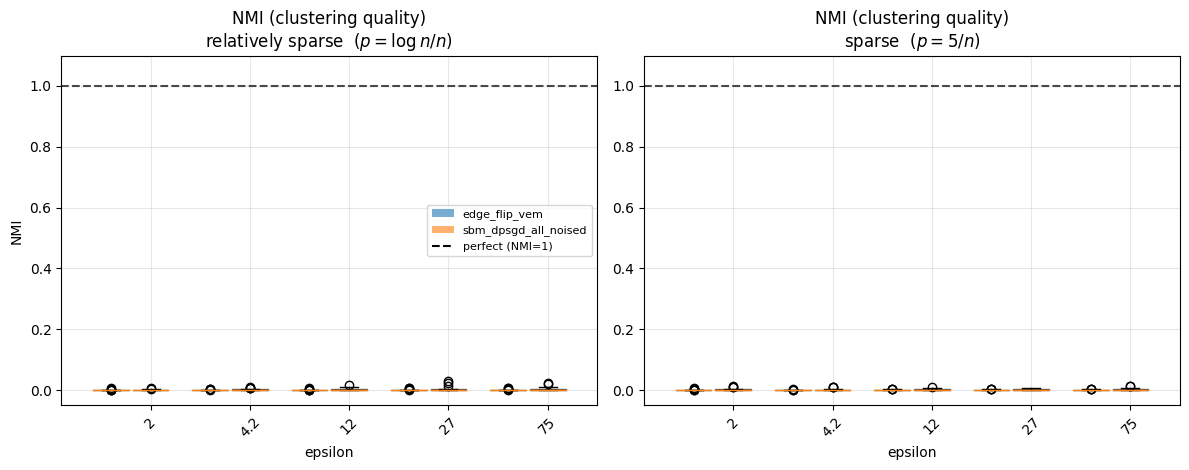

In [4]:

# ── Boxplots of NMI vs epsilon ─────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(regimes), figsize=(6.0 * len(regimes), 4.8), squeeze=False)

for col, regime in enumerate(regimes):
    ax = axes[0, col]
    sub = df[df["regime"] == regime].dropna(subset=["nmi"])
    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    data, positions = [], []
    for e_idx, eps in enumerate(eps_vals):
        for m_idx, method in enumerate(methods):
            vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)]["nmi"]
            if len(vals) == 0:
                continue
            data.append(vals.values)
            positions.append(e_idx + (m_idx - len(methods) / 2) * width)

    bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
        patch.set_alpha(0.6)

    ax.axhline(1.0, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xticks(range(len(eps_vals)))
    ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
    ax.set_title(f"NMI (clustering quality)\n{REGIME_LABEL[regime]}")
    ax.set_xlabel("epsilon")
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("NMI")
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="perfect (NMI=1)"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

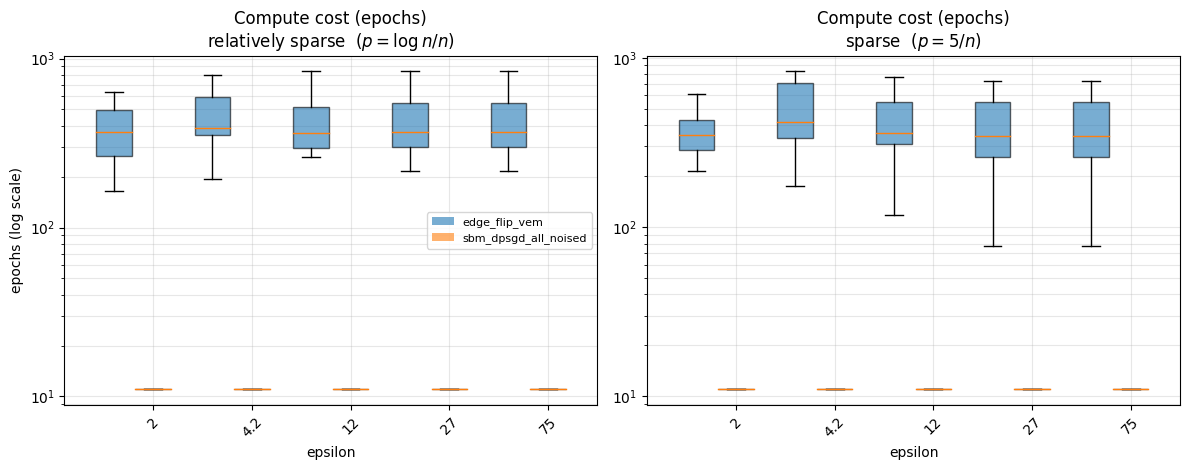

In [5]:

# ── Boxplots of # epochs (compute cost) vs epsilon ─────────────────────────
# Log scale: the two methods differ by ~1-2 orders of magnitude, so a linear
# axis squashes the cheaper one flat against zero.
# CAVEAT (same as the other notebooks): an epoch is NOT wall-clock comparable
# across methods -- a VEM epoch is a dense O(N^2) matmul pass, an SBM-DPSGD
# epoch is a sampled per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(regimes), figsize=(6.0 * len(regimes), 4.8), squeeze=False)

for col, regime in enumerate(regimes):
    ax = axes[0, col]
    sub = df[df["regime"] == regime]
    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    data, positions = [], []
    for e_idx, eps in enumerate(eps_vals):
        for m_idx, method in enumerate(methods):
            vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)]["epochs"]
            if len(vals) == 0:
                continue
            data.append(vals.values)
            positions.append(e_idx + (m_idx - len(methods) / 2) * width)

    bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[(i % len(methods)) % len(colors)])
        patch.set_alpha(0.6)

    ax.set_yscale("log")
    ax.set_xticks(range(len(eps_vals)))
    ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
    ax.set_title(f"Compute cost (epochs)\n{REGIME_LABEL[regime]}")
    ax.set_xlabel("epsilon")
    ax.grid(alpha=0.3, which="both")

axes[0, 0].set_ylabel("epochs (log scale)")
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m)
                for i, m in enumerate(methods)]
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

In [8]:

# ── Summary table: median NMI and median relative beta error per cell ──────
import pandas as pd

tbl = df.copy()
tbl["intra_est"] = tbl[["beta_est_00", "beta_est_11"]].mean(axis=1)
tbl["rel_err_intra"] = (tbl["intra_est"] - tbl["beta_true_00"]).abs() / tbl["beta_true_00"]
tbl["rel_err_inter"] = (tbl["beta_est_01"] - tbl["beta_true_01"]).abs() / tbl["beta_true_01"]

out = (tbl.groupby(["regime", "epsilon", "method"])
          .agg(nmi_median=("nmi", "median"),
               nmi_iqr=("nmi", lambda s: s.quantile(0.75) - s.quantile(0.25)),
               rel_err_intra_median=("rel_err_intra", "median"),
               rel_err_inter_median=("rel_err_inter", "median"),
               epochs_median=("epochs", "median"),
               n=("nmi", "size"))
          .round(4)
          .reset_index())

out["regime"] = pd.Categorical(out["regime"], categories=REGIME_ORDER, ordered=True)
out = out.sort_values(["regime", "epsilon", "method"]).reset_index(drop=True)
display(out)

,regime,epsilon,method,nmi_median,nmi_iqr,rel_err_intra_median,rel_err_inter_median,epochs_median,n
0,relatively_sparse,1.995318,edge_flip_vem,0.0000,0.0001,0.7335,1.0000,366.0,20
1,relatively_sparse,1.995318,sbm_dpsgd_all_noised,0.0007,0.0019,8.2061,3.7069,11.0,20
2,relatively_sparse,4.150006,edge_flip_vem,0.0000,0.0001,0.7190,1.0000,386.0,20
3,relatively_sparse,4.150006,sbm_dpsgd_all_noised,0.0006,0.0022,8.2047,3.7575,11.0,20
4,relatively_sparse,11.732852,edge_flip_vem,0.0000,0.0001,0.7243,1.0000,362.5,20
5,relatively_sparse,11.732852,sbm_dpsgd_all_noised,0.0009,0.0047,8.2251,3.8566,11.0,20
6,relatively_sparse,27.449963,edge_flip_vem,0.0000,0.0003,0.7248,1.0000,369.5,20
7,relatively_sparse,27.449963,sbm_dpsgd_all_noised,0.0016,0.0033,8.2442,3.8416,11.0,20
8,relatively_sparse,75.261074,edge_flip_vem,0.0000,0.0003,0.7248,1.0000,369.5,20
9,relatively_sparse,75.261074,sbm_dpsgd_all_noised,0.0014,0.0048,8.2523,3.8484,11.0,20
